In [48]:
import pandas as pd

In [49]:

def clean_data(df):
    df = df.copy()

    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["livable_surface"] = pd.to_numeric(df["livable_surface"], errors="coerce")

    df = df.dropna(subset=["price", "livable_surface", "province"])
    df = df[df["livable_surface"] > 0]

    df["province"] = df["province"].str.lower()
    df["price_per_m2"] = df["price"] / df["livable_surface"]

    return df

In [50]:
GEO_DATA = {
    "bruxelles": {
        "name": "Bruxelles-Capitale", 
        "provinces": ["brussels"]},
    "flandre": {
        "name": "Flandre", 
        "provinces": [
            "antwerp", 
            "limburg", 
            "east-flanders", 
            "vlaams-brabant", 
            "west-flanders"]},
    "wallonie": {
        "name": "Wallonie", 
        "provinces": [
            "hainaut", 
            "liege", 
            "luxembourg", 
            "namur", 
            "brabant-wallon"]}
}
def province_to_region(df):
    province_to_region = {
        province: region
        for region, info in GEO_DATA.items()
        for province in info["provinces"]
    }
    df["region"] = df["province"].map(province_to_region)
    return df


def compute_metrics(df):
    # Weighted price per m² (MOST IMPORTANT - market truth)
    # weighted = df.groupby("province").apply(
    #     lambda x: x["price"].sum() / x["livable_surface"].sum()
    # ).sort_values(ascending=False)

    weighted = (
        df.groupby("province")[["price", "livable_surface"]]
        .sum()
        .eval("price / livable_surface")
        .sort_values(ascending=False)
    )

    weighted_regions = (
        df.groupby("region")[["price", "livable_surface"]]
        .sum()
        .eval("price / livable_surface")
        .sort_values(ascending=False)
    )

    count = df["province"].value_counts()

    # Variability (robust version using IQR instead of STD)
    iqr = (df.groupby("province")["price_per_m2"].quantile(0.75) - \
          df.groupby("province")["price_per_m2"].quantile(0.25)).sort_values(ascending=False)

    return weighted, weighted_regions, count, iqr

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_dashboard(df, weighted, weighted_regions, count, iqr):
    fig, axes = plt.subplots(2, 3, figsize=(16, 12))
    axes = axes.flatten()

    weighted.plot(kind="bar", ax=axes[0])
    axes[0].set_title("Weighted €/m²")

    weighted_regions.plot(kind="bar", ax=axes[1])
    axes[1].set_title("Weighted regions €/m²")

    count.plot(kind="bar", ax=axes[2])
    axes[2].set_title("Number of Properties")

    iqr.plot(kind="bar", ax=axes[3])
    axes[3].set_title("Market Variability (IQR)")

    sns.boxplot(data=df, x="province", y="price_per_m2", ax=axes[4])

    axes[4].set_title("Distribution (Boxplot)")
    axes[4].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

In [52]:
def generate_insights(weighted, weighted_regions, count, iqr):
    return f"""
    📊 REAL ESTATE INSIGHTS

    💰 Most expensive: {weighted.idxmax()}
    💸 Cheapest: {weighted.idxmin()}

    💰 Most expensive region: {weighted_regions.idxmax()}
    💸 Cheapest region: {weighted_regions.idxmin()}

    📦 Most data: {count.idxmax()}
    📉 Least data: {count.idxmin()}

    📊 Most volatile: {iqr.idxmax()}
    📊 Most stable: {iqr.idxmin()}
    """

In [53]:
def format_insight_block(weighted, weighted_regions, count, iqr):
    most_expensive = weighted.idxmax()
    cheapest = weighted.idxmin()

    most_data = count.idxmax()
    least_data = count.idxmin()

    most_volatile = iqr.idxmax()
    most_stable = iqr.idxmin()

    text = f"""
    <b>📊 REAL ESTATE INSIGHTS REPORT (BELGIUM)</b><br/><br/>

    <b>💰 Price Level:</b><br/>
    - Most expensive province: {most_expensive}<br/>
    - Cheapest province: {cheapest}<br/><br/>

    <b>📦 Data Coverage:</b><br/>
    - Most listings: {most_data}<br/>
    - Least represented: {least_data}<br/><br/>

    <b>📉 Market Stability:</b><br/>
    - Most volatile (uneven prices): {most_volatile}<br/>
    - Most stable market: {most_stable}<br/><br/>

    <b>🧠 Key Insight:</b><br/>
    - High-priced provinces tend to show higher variability, indicating a mix of luxury and standard properties.<br/>
    - Data coverage is uneven across provinces, which may bias comparisons in low-sample regions.
    """

    return text

In [54]:
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from reportlab.platypus import PageBreak


def generate_pdf_report(df, weighted, weighted_regions, count, iqr, insight_text, output="report_prices_per_m2_provinces_cities.pdf"):
    """
    Generate a full business-style real estate PDF report including:
    - Title
    - Executive insights
    - Key metrics table
    - Dashboard chart image
    """

    # =========================
    # INIT PDF
    # =========================
    doc = SimpleDocTemplate(output)
    styles = getSampleStyleSheet()
    elements = []

    # =========================
    # TITLE
    # =========================
    title = Paragraph(
        "Belgium Real Estate Market Report",
        styles["Title"]
    )
    elements.append(title)
    elements.append(Spacer(1, 12))

    # =========================
    # EXECUTIVE INSIGHTS
    # =========================
    elements.append(Paragraph("<b>Executive Insights</b>", styles["Heading2"]))
    elements.append(Spacer(1, 6))

    elements.append(Paragraph(insight_text, styles["Normal"]))
    elements.append(Spacer(1, 12))

    # =========================
    # METRICS TABLE
    # =========================
    elements.append(Paragraph("<b>Market Overview Table</b>", styles["Heading2"]))
    elements.append(Spacer(1, 6))

    table_data = [["Province", "Weighted €/m²", "Listings", "IQR"]]

    for province in weighted.index:
        table_data.append([
            province,
            round(weighted[province], 2),
            int(count[province]),
            round(iqr[province], 2)
        ])

    table = Table(table_data)

    table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.whitesmoke),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
        ("PADDING", (0, 0), (-1, -1), 6),
        ("ALIGN", (0, 0), (-1, -1), "CENTER"),
    ]))

    elements.append(table)
    elements.append(Spacer(1, 12))


    elements.append(Paragraph("<b>Regions Market Overview Table</b>", styles["Heading2"]))
    elements.append(Spacer(1, 6))

    region_table_data = [["Region", "Weighted €/m²", "Listings", "IQR"]]

    for region in weighted_regions.index:
        region_table_data.append([
            region,
            round(weighted_regions.get(region, 0), 2),
            int(count.get(region, 0)),
            round(iqr.get(region, 0), 2)
        ])

    region_table = Table(region_table_data)

    region_table.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.whitesmoke),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.black),
        ("PADDING", (0, 0), (-1, -1), 6),
        ("ALIGN", (0, 0), (-1, -1), "CENTER"),
    ]))

    elements.append(region_table)
    elements.append(Spacer(1, 12))


    # =========================
    # DASHBOARD IMAGE
    # =========================
    elements.append(PageBreak())
    elements.append(Paragraph("<b>Visual Dashboard</b>", styles["Heading2"]))
    elements.append(Spacer(1, 6))

    try:
        elements.append(Image("province_dashboard.png", width=500, height=350))
    except:
        elements.append(Paragraph("Dashboard image not found.", styles["Normal"]))

    # =========================
    # BUILD PDF
    # =========================
    doc.build(elements)

    print(f"PDF saved successfully → {output}")

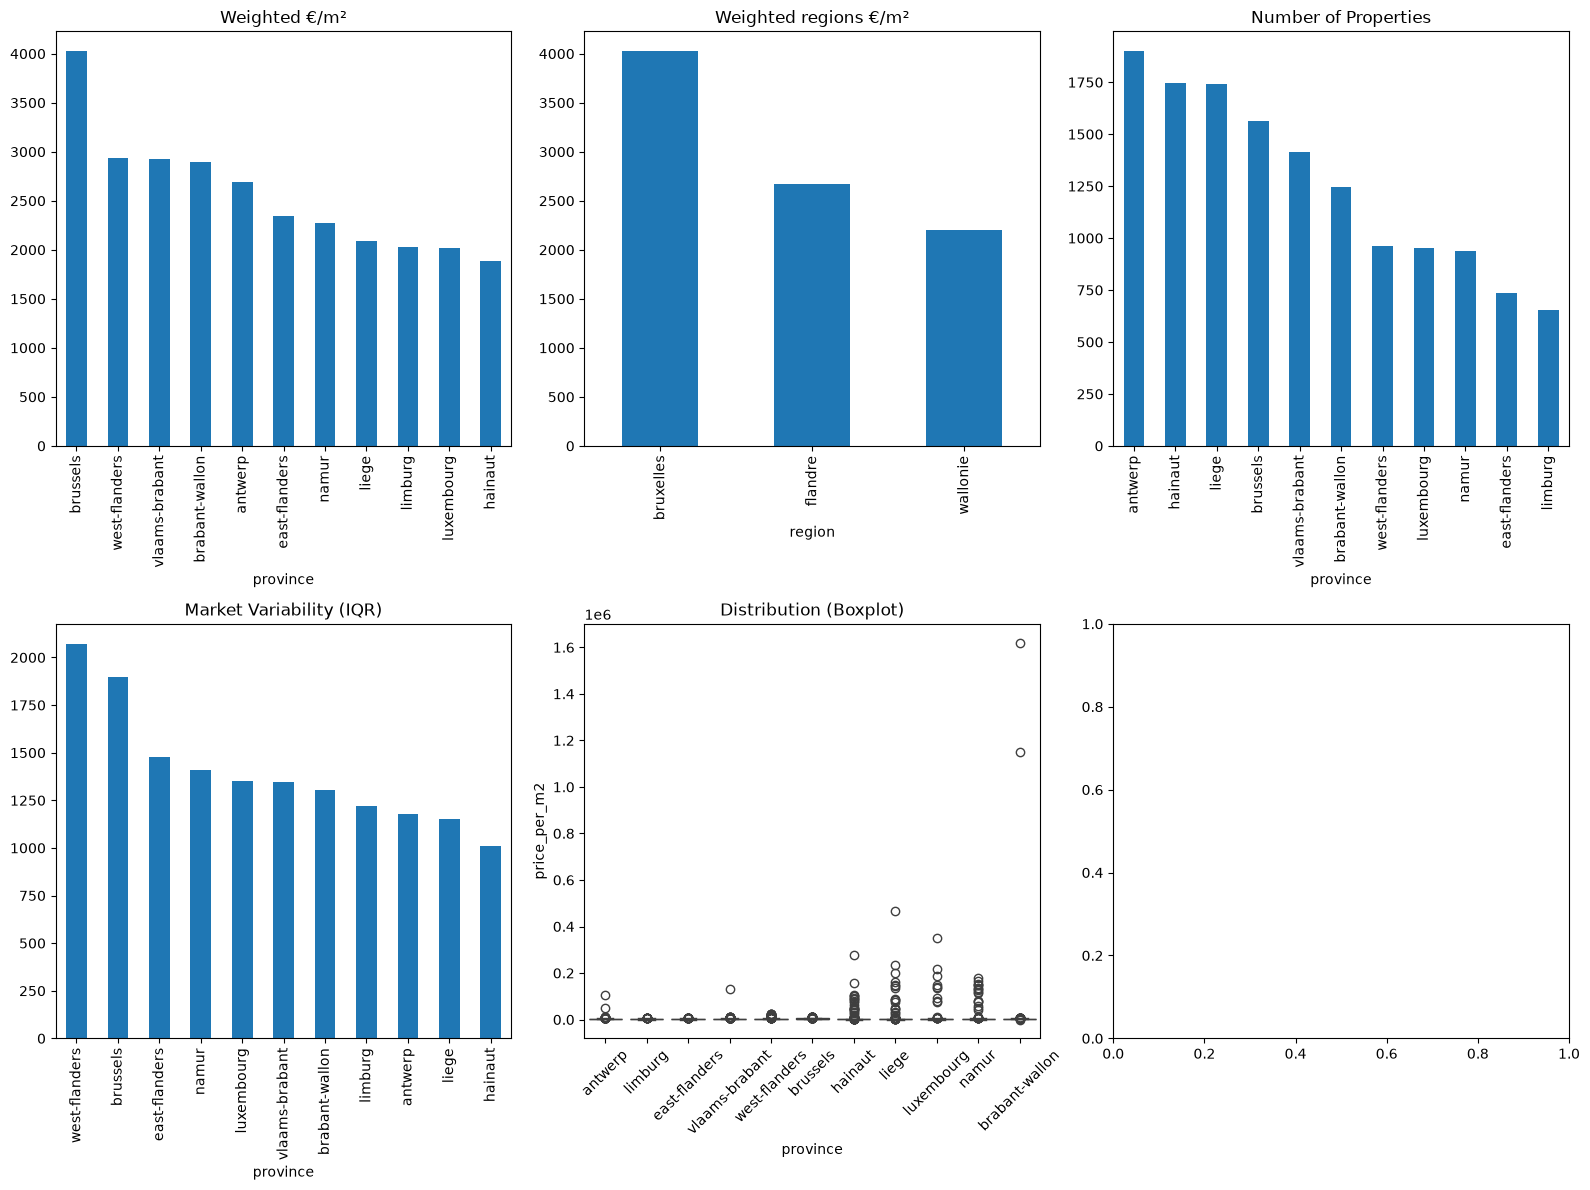

PDF saved successfully → report_prices_per_m2_provinces_cities.pdf


In [56]:
df = pd.read_json("../../data/cleaned/clean_dataframe_fixed.json")

df_clean = clean_data(df)
df_clean = province_to_region(df_clean) 
weighted, weighted_regions, count, iqr = compute_metrics(df_clean)

insight_text = generate_insights(weighted, weighted_regions, count, iqr)

plot_dashboard(df_clean, weighted, weighted_regions, count, iqr)

generate_pdf_report(df_clean, weighted, weighted_regions, count, iqr, insight_text)